In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# =========================
# Load files
# =========================
baseline = pd.read_csv("../data/tangier_synthetic_water_model_with_supply_2000_2035.csv")
print(baseline.columns)



Index(['date', 'year', 'month', 'population', 'rainfall_mm', 'temperature_c',
       'evaporation_mcm', 'total_demand_mcm', 'storage_baseline_mcm',
       'storage_rain_minus3_mcm', 'storage_rain_minus5_mcm', 'stress_baseline',
       'stress_rain_minus3', 'stress_rain_minus5', 'delta_storage',
       'supply_mcm'],
      dtype='object')


In [3]:
food = pd.read_csv("../data/tangier_synthetic_water_food_self_sufficiency_2000_2035.csv")
print(food.columns)

Index(['date', 'year', 'month', 'population', 'rainfall_mm', 'temperature_c',
       'inflow_mcm', 'losses_mcm', 'supply_mcm', 'domestic_demand_mcm',
       'agricultural_demand_mcm', 'industrial_demand_mcm', 'total_demand_mcm',
       'storage_mcm', 'stress_index_demand_over_supply',
       'stress_index_demand_over_storage', 'scenario'],
      dtype='object')


In [4]:
virtual = pd.read_csv("../data/tangier_synthetic_water_virtual_water_2000_2035.csv")
print(virtual.columns)

Index(['date', 'year', 'month', 'population', 'rainfall_mm', 'temperature_c',
       'inflow_mcm', 'losses_mcm', 'supply_mcm', 'domestic_demand_mcm',
       'agricultural_demand_mcm', 'industrial_demand_mcm', 'total_demand_mcm',
       'storage_mcm', 'stress_index_demand_over_supply',
       'stress_index_demand_over_storage', 'scenario'],
      dtype='object')


In [5]:
# =========================
# Standardize date
# =========================
for df in [baseline, virtual, food]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)

In [6]:
# =========================
# Make baseline schema compatible
# =========================
baseline = baseline.rename(columns={
    "storage_baseline_mcm": "storage_mcm"
})

baseline["scenario"] = "baseline"

In [7]:

# Keep only common useful columns
baseline = baseline[[
    "date", "year", "month", "population",
    "rainfall_mm", "temperature_c",
    "supply_mcm", "total_demand_mcm", "storage_mcm", "scenario"
]]

virtual = virtual[[
    "date", "year", "month", "population",
    "rainfall_mm", "temperature_c",
    "supply_mcm", "total_demand_mcm", "storage_mcm", "scenario"
]]

food = food[[
    "date", "year", "month", "population",
    "rainfall_mm", "temperature_c",
    "supply_mcm", "total_demand_mcm", "storage_mcm", "scenario"
]]

In [8]:
# Convert date
for df in [baseline, virtual, food]:
    df["date"] = pd.to_datetime(df["date"])


In [9]:
# Merge everything
df_all = pd.concat([baseline, virtual, food], ignore_index=True)

# Scenario flags
df_all["is_baseline"] = (df_all["scenario"] == "baseline").astype(int)
df_all["is_virtual_water"] = (df_all["scenario"] == "virtual_water").astype(int)
df_all["is_food_self_sufficiency"] = (df_all["scenario"] == "food_self_sufficiency").astype(int)

print("df_all created successfully!")
print(df_all.head())

df_all created successfully!
        date  year  month  population  rainfall_mm  temperature_c  supply_mcm  \
0 2000-01-01  2000      1      661516       103.05          17.91      20.342   
1 2000-02-01  2000      2      663405        84.24          19.72      29.082   
2 2000-03-01  2000      3      665294        87.50          23.85      19.621   
3 2000-04-01  2000      4      667184        69.41          23.58      20.475   
4 2000-05-01  2000      5      669073        20.49          22.82      12.493   

   total_demand_mcm  storage_mcm  scenario  is_baseline  is_virtual_water  \
0            20.342      180.000  baseline            1                 0   
1            28.142      180.940  baseline            1                 0   
2            30.467      170.094  baseline            1                 0   
3            33.043      157.526  baseline            1                 0   
4            31.432      138.587  baseline            1                 0   

   is_food_self_suffi

In [10]:
val_end = pd.Timestamp("2025-12-01")
scenarios = ["baseline", "virtual_water", "food_self_sufficiency"]

for scen in scenarios:
    df_s = df_all[df_all["scenario"] == scen]
    test_df = df_s[df_s["date"] > val_end]

    print("\n=== Scenario:", scen, "===")
    print("Samples:", len(test_df))


=== Scenario: baseline ===
Samples: 120

=== Scenario: virtual_water ===
Samples: 120

=== Scenario: food_self_sufficiency ===
Samples: 120


In [11]:
feature_cols = [
    "population",
    "rainfall_mm",
    "temperature_c",
    "supply_mcm",
    "storage_mcm",
    "is_baseline",
    "is_virtual_water",
    "is_food_self_sufficiency"
]

target_cols = [
    "total_demand_mcm",
    "supply_mcm"
]


In [12]:
seq_length = 12

def make_sequences(X, y, seq_length=12):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

In [13]:
# split chronologically inside each scenario
train_end = pd.Timestamp("2021-12-01")
val_end = pd.Timestamp("2025-12-01")

X_train_all, y_train_all = [], []
X_val_all, y_val_all = [], []
X_test_all, y_test_all = [], []

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [14]:
# fit scalers only on training rows from all scenarios
train_rows = df_all[df_all["date"] <= train_end]
X_scaler.fit(train_rows[feature_cols])
y_scaler.fit(train_rows[target_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [15]:
for scen in df_all["scenario"].unique():
    df_s = df_all[df_all["scenario"] == scen].copy()

    train_df = df_s[df_s["date"] <= train_end]
    val_df = df_s[(df_s["date"] > train_end) & (df_s["date"] <= val_end)]
    test_df = df_s[df_s["date"] > val_end]

    X_train = X_scaler.transform(train_df[feature_cols])
    y_train = y_scaler.transform(train_df[target_cols])

    X_val = X_scaler.transform(val_df[feature_cols])
    y_val = y_scaler.transform(val_df[target_cols])

    X_test = X_scaler.transform(test_df[feature_cols])
    y_test = y_scaler.transform(test_df[target_cols])

    X_train_seq, y_train_seq = make_sequences(X_train, y_train, seq_length)
    X_val_seq, y_val_seq = make_sequences(X_val, y_val, seq_length)
    X_test_seq, y_test_seq = make_sequences(X_test, y_test, seq_length)

    X_train_all.append(X_train_seq)
    y_train_all.append(y_train_seq)

    X_val_all.append(X_val_seq)
    y_val_all.append(y_val_seq)

    X_test_all.append(X_test_seq)
    y_test_all.append(y_test_seq)

X_train_seq = np.concatenate(X_train_all, axis=0)
y_train_seq = np.concatenate(y_train_all, axis=0)

X_val_seq = np.concatenate(X_val_all, axis=0)
y_val_seq = np.concatenate(y_val_all, axis=0)

X_test_seq = np.concatenate(X_test_all, axis=0)
y_test_seq = np.concatenate(y_test_all, axis=0)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Val:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

Train: (756, 12, 8) (756, 2)
Val: (108, 12, 8) (108, 2)
Test: (324, 12, 8) (324, 2)


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(seq_length, X_train_seq.shape[2])),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(2)   # demand + supply
])

model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ],
    verbose=1
)

I0000 00:00:1774563593.697796   24048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774563593.999151   24048 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774563595.178259   24048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Epoch 1/200


W0000 00:00:1774563595.755875   24188 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774563596.007130   24048 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0951 - mae: 0.2381 - val_loss: 0.0556 - val_mae: 0.1908
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0488 - mae: 0.1811 - val_loss: 0.0455 - val_mae: 0.1748
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0403 - mae: 0.1641 - val_loss: 0.0314 - val_mae: 0.1467
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0287 - mae: 0.1376 - val_loss: 0.0186 - val_mae: 0.1145
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0193 - mae: 0.1104 - val_loss: 0.0082 - val_mae: 0.0721
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0123 - mae: 0.0866 - val_loss: 0.0061 - val_mae: 0.0613
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0100 - mae: 0.0787 - val_loss: 0.0042 - val_mae: 0.0507
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - mae: 0.0755 - val_loss: 0.0045 - val_mae: 0.0524
Epoch 9/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0082 - mae: 0.0

In [17]:
y_pred_scaled = model.predict(X_test_seq)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_seq)

demand_pred = y_pred[:, 0]
supply_pred = y_pred[:, 1]

demand_true = y_true[:, 0]
supply_true = y_true[:, 1]

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [18]:
# Build aligned test dataframe per scenario
test_df_list = []

for scen in df_all["scenario"].unique():
    df_s = df_all[df_all["scenario"] == scen].copy()
    test_df = df_s[df_s["date"] > val_end].copy()

    # align exactly the same way sequences were built
    test_df = test_df.iloc[seq_length:].copy()

    test_df_list.append(test_df)

test_df_all = pd.concat(test_df_list, ignore_index=True)

print("Aligned test rows:", len(test_df_all))
print("Prediction rows:", len(demand_pred))

# Attach predictions
test_df_all["demand_true"] = demand_true
test_df_all["demand_pred"] = demand_pred
test_df_all["supply_true"] = supply_true
test_df_all["supply_pred"] = supply_pred

Aligned test rows: 324
Prediction rows: 324


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

for scen in ["baseline", "virtual_water", "food_self_sufficiency"]:
    
    df_s = test_df_all[test_df_all["scenario"] == scen]
    
    print("\n=== Scenario:", scen, "===")
    
    print("Demand MAE:", mean_absolute_error(df_s["demand_true"], df_s["demand_pred"]))
    print("Demand RMSE:", np.sqrt(mean_squared_error(df_s["demand_true"], df_s["demand_pred"])))
    
    print("Supply MAE:", mean_absolute_error(df_s["supply_true"], df_s["supply_pred"]))
    print("Supply RMSE:", np.sqrt(mean_squared_error(df_s["supply_true"], df_s["supply_pred"])))


=== Scenario: baseline ===
Demand MAE: 1.3742248537275528
Demand RMSE: 1.662889523872691
Supply MAE: 2.0134548859066435
Supply RMSE: 2.5983652251519582

=== Scenario: virtual_water ===
Demand MAE: 1.7923355488953772
Demand RMSE: 2.1805462288166835
Supply MAE: 2.5615825312932325
Supply RMSE: 3.0952883532641615

=== Scenario: food_self_sufficiency ===
Demand MAE: 3.6511387132008872
Demand RMSE: 4.545733401831326
Supply MAE: 2.4534894259594098
Supply RMSE: 3.02019977613756


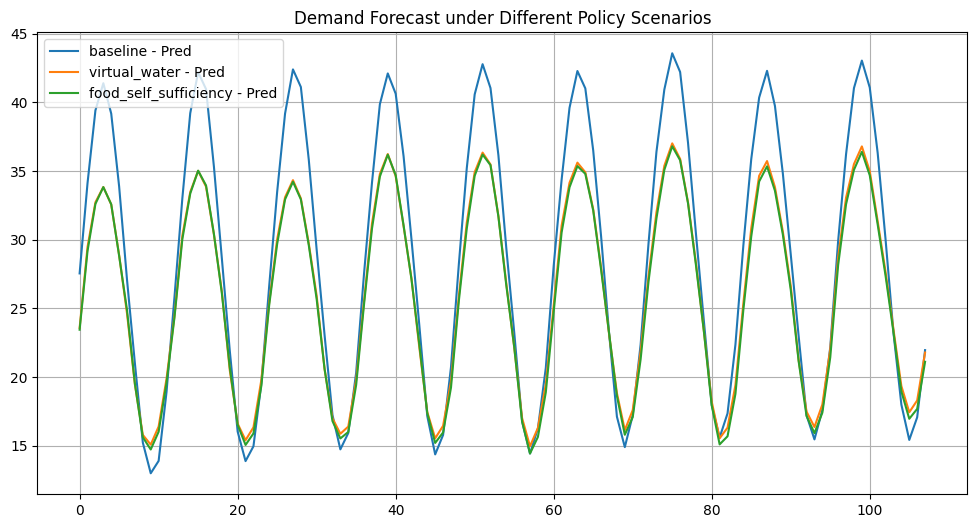

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for scen in ["baseline", "virtual_water", "food_self_sufficiency"]:
    df_s = test_df_all[test_df_all["scenario"] == scen]
    plt.plot(df_s["demand_pred"].values, label=f"{scen} - Pred")

plt.title("Demand Forecast under Different Policy Scenarios")
plt.legend()
plt.grid()
plt.show()

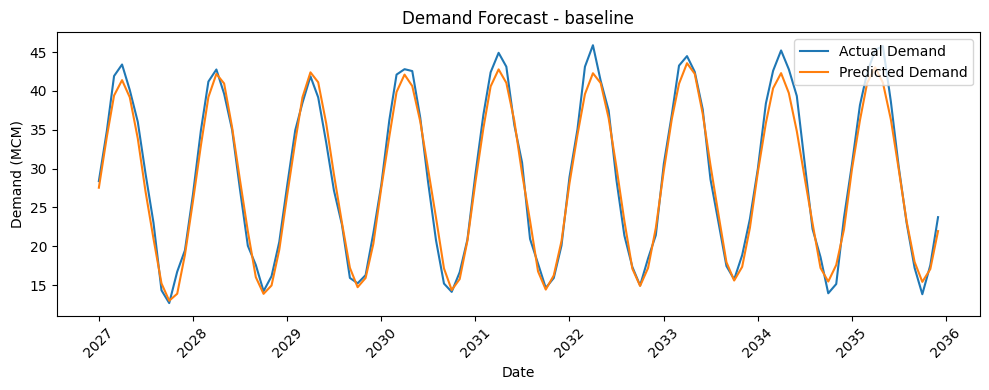

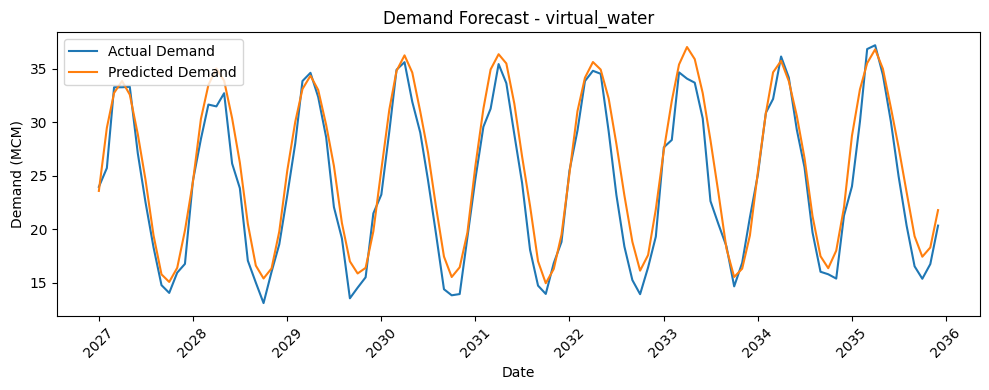

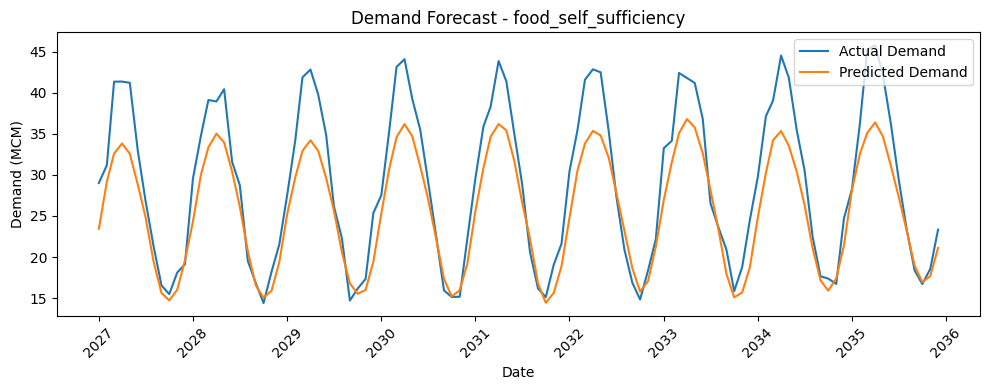

In [21]:
import matplotlib.pyplot as plt

for scen in ["baseline", "virtual_water", "food_self_sufficiency"]:
    df_s = test_df_all[test_df_all["scenario"] == scen].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(df_s["date"], df_s["demand_true"], label="Actual Demand")
    plt.plot(df_s["date"], df_s["demand_pred"], label="Predicted Demand")
    plt.title(f"Demand Forecast - {scen}")
    plt.xlabel("Date")
    plt.ylabel("Demand (MCM)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"demand_{scen}.png", dpi=300)
    plt.show()

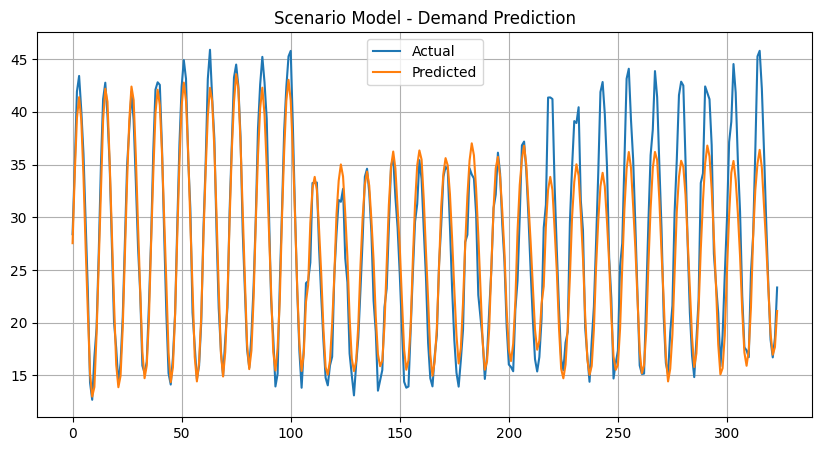

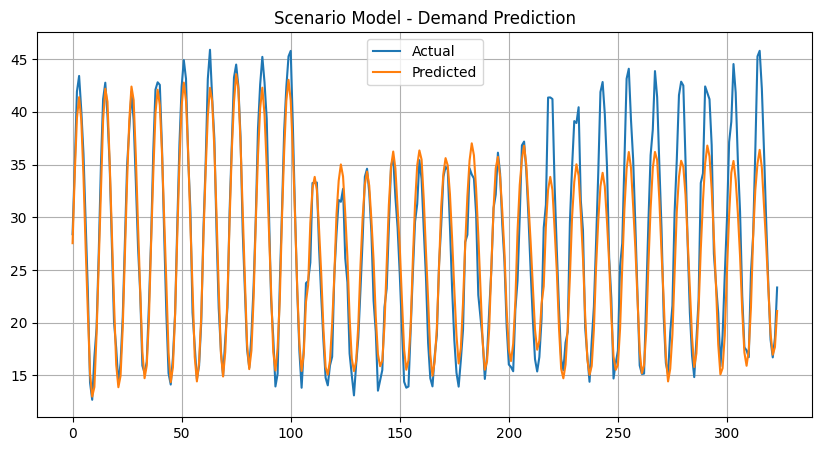

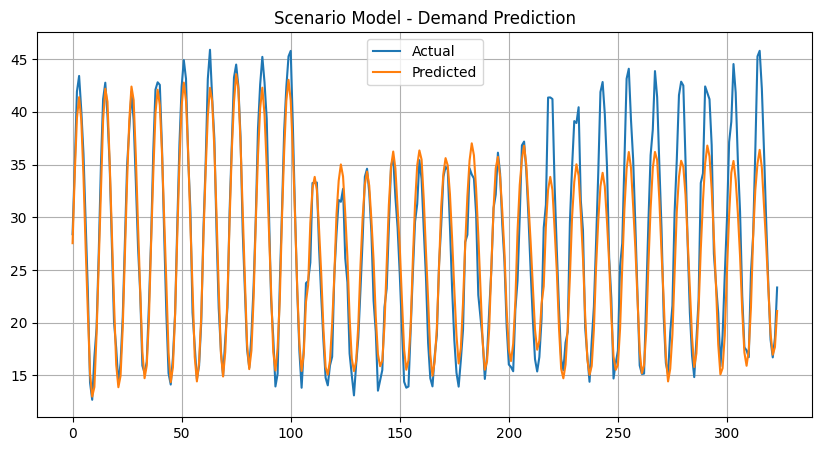

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(demand_true, label="Actual")
plt.plot(demand_pred, label="Predicted")
plt.title("Scenario Model - Demand Prediction")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(demand_true, label="Actual")
plt.plot(demand_pred, label="Predicted")
plt.title("Scenario Model - Demand Prediction")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(demand_true, label="Actual")
plt.plot(demand_pred, label="Predicted")
plt.title("Scenario Model - Demand Prediction")
plt.legend()
plt.grid()
plt.show()